In [1]:
import pandas as pd
import numpy as np
import math
import warnings

def addColumns(data):
    #Add Responders vs Non Responder:
    # Responders: CR/PR, Non responder: PD
    responderCrit = data['BR'].isin(['CR','PR'])
    progressorCrit = data['BR'].isin(['PD'])

    
    data["PD_Responders"] = "SD/MR"
    responders = data[responderCrit].index
    progressors = data[progressorCrit].index
    nonresponders = data[~responderCrit].index
    nonprogressors = data[~progressorCrit].index
    
    data.loc[responders,"PD_Responders"] = 'Responder'
    data.loc[progressors,"PD_Responders"] = 'Progressor'

    data["PD_nonPD"] = 0
    data.loc[progressors, "PD_nonPD"] = 1

    #Add log neoantigen columns:
    neoantigen_cols = ["nonsyn_muts", "clonal_muts","subclonal_muts","total_neoantigens"]
    for col in neoantigen_cols:
        log_col = f"log_{col}"
        log_values = []
        for x in data[col]:
            if x < 0:
                warnings.warn(
                    f"There is abnormal value in the {col} column.",
                    DeprecationWarning,
                )
                log_values.append(math.log((0+1e-9), 10))
            else:
                log_values.append(math.log((x+1e-9), 10))
        data[log_col] = log_values
    return data
                
seed = 42
syn_datas = ["original_data",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
dataset_dict = {}
for syn_data in syn_datas:
    print(f"-----{syn_data}-----")
    df = pd.read_csv(f"Data/{syn_data}.csv",index_col = 0)
    processed_df = addColumns(df)
    processed_df['LN_Met'] = processed_df['LN_Met'].astype(int)
    dataset_dict[syn_data] = processed_df

-----original_data-----
-----avatarsk10_42-----
-----ctgan_42-----


/tmp/ipykernel_3696262/2822325961.py:32: DeprecationWarning: There is abnormal value in the nonsyn_muts column.
  warnings.warn(
/tmp/ipykernel_3696262/2822325961.py:32: DeprecationWarning: There is abnormal value in the clonal_muts column.
  warnings.warn(
/tmp/ipykernel_3696262/2822325961.py:32: DeprecationWarning: There is abnormal value in the subclonal_muts column.
  warnings.warn(
/tmp/ipykernel_3696262/2822325961.py:32: DeprecationWarning: There is abnormal value in the total_neoantigens column.
  warnings.warn(


-----gaussiancopula_42-----
-----synthpop_42-----
-----tvae_42-----


/tmp/ipykernel_3696262/2822325961.py:32: DeprecationWarning: There is abnormal value in the nonsyn_muts column.
  warnings.warn(
/tmp/ipykernel_3696262/2822325961.py:32: DeprecationWarning: There is abnormal value in the clonal_muts column.
  warnings.warn(
/tmp/ipykernel_3696262/2822325961.py:32: DeprecationWarning: There is abnormal value in the subclonal_muts column.
  warnings.warn(
/tmp/ipykernel_3696262/2822325961.py:32: DeprecationWarning: There is abnormal value in the total_neoantigens column.
  warnings.warn(


In [2]:
def GenRegDF (df, categVars, quantVars, outcome = None):
    # grab the patients with valid outcomes
    if outcome is not None:
        regDF = df[df[outcome].apply(np.isreal) & ~df[outcome].isnull()][[outcome] + quantVars] # get ones with outcomes
    else:
        regDF = df[quantVars]
        
    nullQuants = []
    for quantVar in quantVars:
        # clean up quantitative variables for missing values and non-quantitative values
        regDF.loc[regDF.index, quantVar] = pd.to_numeric(regDF[quantVar], errors = 'coerce') # convert to numeric, NaN if not numeric
        if sum(regDF[quantVar].isnull()) > 0:
            print(quantVar,"has", sum(regDF[quantVar].isnull()),"null values")
            nullQuants += [quantVar]

        median = regDF[quantVar].median()
        # print(quantVar, "median:", median)
        aboveMedian = regDF[quantVar] > median
        belowMedian = regDF[quantVar] <= median

        regDF.loc[:,quantVar + "_upper"] = 0
        regDF.loc[aboveMedian, quantVar + "_upper"] = 1

        regDF.loc[:,quantVar + "_lower"] = 0
        regDF.loc[belowMedian, quantVar + "_lower"] = 1

    # generate dummy variables for categorical variables
    for categVar in categVars:
        dummyDF = pd.get_dummies(df[categVar], prefix=categVar)
        cols = dummyDF.columns
        regDF = regDF.merge(dummyDF.iloc[:,1:], left_index=True, right_index = True)

    # rescale variables
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0,1))
    goodFeatures = [x for x in regDF.columns if x not in nullQuants]
    tempDF = pd.DataFrame(scaler.fit_transform(regDF[goodFeatures]), index = regDF.index, columns = goodFeatures)
    tempDF[nullQuants] = regDF[nullQuants] # pass through without scaling
    regDF = tempDF

    # generate intercept
    regDF['intercept'] = 1
    # print("Total variables in regression DF:", len(regDF.columns) - 1)
    return regDF

In [3]:
fullProcessedData = {}
for tool in dataset_dict.keys():
    res_wide = pd.read_csv(f"ssGSEA/ssGSEA_{tool}_{seed}.csv", index_col = 0)
    fullDF = dataset_dict[tool]
    quantVars = [
                'log_nonsyn_muts',
                  'heterogeneity',
                  'purity',
                    'ploidy',
                   'Tx_Start_LDH',
                    ]
    
    categVars = [
                    'LN_Met',
                ]
    
    # generate response groups stratified by prior ipilimumab treatment status
    # Generate a category for allRNADF to compare nonresponders (ipi-experienced) vs nonresponders (ipi-naive)
    ipiTreated = fullDF[fullDF["daysBiopsyAfterIpiStart"]!="noIpi"].index
    postIpi = list(fullDF[fullDF["daysBiopsyAfterIpiStart"]=="postIpi"].index)
    preIpi = list(fullDF[fullDF["daysBiopsyAfterIpiStart"]=="preIpi"].index)
    noIpi = list(fullDF[fullDF["daysBiopsyAfterIpiStart"]=="noIpi"].index)
    
    progressors = list(fullDF[fullDF['PD_Responders']=="Progressor"].index)
    responders = list(fullDF[fullDF['PD_Responders']=="Responder"].index)
    nonprogressors = list(fullDF[fullDF['PD_nonPD']==0].index)
    
    PDpostIpi = list(set(postIpi).intersection(set(progressors)))
    PDnoIpi = list(set(noIpi).intersection(set(progressors)))
    RpostIpi = list(set(postIpi).intersection(set(responders)))
    RnoIpi = list(set(noIpi).intersection(set(responders)))
    nPDpostIpi = [x for x in postIpi if x not in progressors] 
    nPDnoIpi = [x for x in noIpi if x not in progressors] 
    
    # create a set of regression DFs for each comparison and cohort, e.g. regDFs['Ipi-exp PDvsnPD']
    regDFs = {}
    
    # generate regression DF for hallmark signatures
    variables = res_wide.columns 
    outcomeGroups = {'Ipi_Exp': [PDpostIpi, nPDpostIpi],
                    'Ipi_Naive': [PDnoIpi, nPDnoIpi],
                     'PD_nPD': [progressors, nonprogressors],
                    }
    for outcome in outcomeGroups:
        group1 = [x for x in outcomeGroups[outcome][0] if x in res_wide.index]
        group0 = [x for x in outcomeGroups[outcome][1] if x in res_wide.index]
        tempDF = res_wide.copy()
        tempDF.loc[group1, 'outcome'] = 1
        tempDF.loc[group0, 'outcome'] = 0
        # remove rows with 'na' as outcome
        tempDF = tempDF[~tempDF['outcome'].isnull()]
        regDFs[outcome] = tempDF
        # print(outcome,":",len(tempDF.index),'patients and', len(tempDF.columns),'signatures')
    fullRegDFs = {}
    outcomeGroups = ['Ipi_Exp',
                     'Ipi_Naive',
                    'PD_nPD',
                    ]
    for outcome in outcomeGroups:
        regDF = regDFs[outcome]
    
        # print(len(regDF.index),"entries in regDF")
    
        # generate the regDF for DNA and clinical variables
        tempDF = GenRegDF(fullDF[categVars + quantVars], categVars, quantVars)
        # print(len(tempDF.index),"entries in tempDF")
    
        # join with our existing DF and the single cell sigantures
        regDF = regDF.merge(tempDF, how='inner', left_index=True, right_index=True)
    
        # remove variables with variance 0
        regDF = regDF.loc[:,regDF.var() != 0]
    
        # add intercept
        regDF['intercept'] = 1
    
        # save off
        fullRegDFs[outcome] = regDF
    fullProcessedData[tool] = fullRegDFs

In [12]:
def _statistical_test(scores_a, scores_b) -> float:
    differences = np.array(scores_a) - np.array(scores_b)
    if np.all(differences == 0):
        return 1.0
    _, p_value = wilcoxon(scores_a, scores_b, alternative="two-sided")
    return p_value
    
def compare_cross_validation(
    real,
    synth,
    target_col,
    model,
    cv, 
    metric, 
    output_dir: str = ".",
    scaler: str = "minmax",
    n_neighbors: int = 5,
    return_full_scores: bool = True,
    save: bool = True,
    n_jobs = -1
) -> dict:

    X_real = real.drop(columns=[target_col])
    y_real = real[target_col]
    X_synth = synth.drop(columns=[target_col])
    y_synth = synth[target_col]

    rkf = cv
    scorer = get_scorer(metric)
    # orig_scores, synth_scores = [], []

    real_folds = list(rkf.split(X_real, y_real))
    synth_folds = list(rkf.split(X_synth, y_synth))
    
    def fit_and_score(real_train_idx, real_test_idx, synth_train_idx):
        X_real_train, X_real_test = (
            X_real.iloc[real_train_idx],
            X_real.iloc[real_test_idx],
        )
        y_real_train, y_real_test = (
            y_real.iloc[real_train_idx],
            y_real.iloc[real_test_idx],
        )

        X_synth_train = X_synth.iloc[synth_train_idx]
        y_synth_train = y_synth.iloc[synth_train_idx]

        # Try to set n_jobs if supported
        # try:
        model_real = clone(model)
        # except ValueError:
            # model_real = clone(self.model)
        model_real.fit(X_real_train, y_real_train)
        orig_score = scorer(model_real, X_real_test, y_real_test)

        # try:
            # model_synth = clone(self.model).set_params(n_jobs=self.n_jobs)
        # except ValueError:
        model_synth = clone(model)
        model_synth.fit(X_synth_train, y_synth_train)
        synth_score = scorer(model_synth, X_real_test, y_real_test)
        return orig_score, synth_score

    results = Parallel(n_jobs=n_jobs)(
        delayed(fit_and_score)(real_train_idx, real_test_idx, synth_train_idx)
        for (real_train_idx, real_test_idx), (synth_train_idx, _) in zip(real_folds, synth_folds)
    )
    orig_scores, synth_scores = zip(*results)

    p_value = _statistical_test(orig_scores, synth_scores)
    is_improved = np.mean(orig_scores) <= np.mean(synth_scores)

    if return_full_scores:
        compare_cross_validation_result = {
            "real_scores": orig_scores,
            "synthetic_scores": synth_scores,
            "is_improved": is_improved,
            "p_value": p_value,
        }
    else:
        compare_cross_validation_result = {
            "real_scores": [np.mean(orig_scores), np.std(orig_scores)],
            "synthetic_scores": [np.mean(synth_scores), np.std(synth_scores)],
            "is_improved": is_improved,
            "p_value": p_value,
        }
    # if save:
    #     filepath = os.path.join(output_dir, "compare_cross_validation_result.json")
    #     with open(filepath, "w") as f:
    #         json.dump(compare_cross_validation_result, f, indent=4)
    return compare_cross_validation_result

### **Ipi Treated Group**

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import get_scorer
from sklearn.neural_network import MLPClassifier
from joblib import Parallel, delayed
from scipy.stats import wilcoxon
from sklearn.base import clone
import pickle
import os
import json
models = {
    "Logistic_Regression": LogisticRegression(penalty = 'l2', max_iter = 100000, random_state=42, solver='lbfgs', n_jobs=-1),
    "SVM": SVC(probability = True, max_iter = 10000),
    "Random_Forest": RandomForestClassifier(random_state=42, n_jobs = -1),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42, thread_count=-1),
    "MLP":  MLPClassifier(alpha = 0.01, max_iter = 10000, validation_fraction = 0.1, random_state = 42, hidden_layer_sizes = 150)
}

In [29]:
n_splits = 5
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
n_neighbors = 5
return_full_scores = True

case = 'Ipi_Exp'
features = ['MHC-II','LN_Met_1','Tx_Start_LDH_lower','outcome']
syn_name = 'gaussiancopula_42'
ori =  fullProcessedData['original_data'][case][features]
synth = fullProcessedData[syn_name][case][features]

In [30]:
metric_results_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_IpiTreated = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_cv[model_name] = cross_IpiTreated

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
def plot_violin_metric_pairs(metric_results, model_names, metric_name="Accuracy"):
    """
    Plot violin plots for pairs of metric outputs from multiple algorithms, with group means overlaid and labeled.

    Args:
        metric_results (dict): Dictionary where keys are algorithm names, 
            and values are tuples or lists of (real_scores, synthetic_scores),
            each being a list or np.ndarray of metric values.
        model_names (list): List of algorithm names in desired order.
        metric_name (str): Name of the metric for labeling.

    Returns:
        None
    """
    # Prepare data for plotting
    flat_scores = []
    flat_model = []
    flat_type = []
    for model in model_names:
        real_scores = metric_results[model]['real_scores']
        synth_scores = metric_results[model]['synthetic_scores']
        flat_scores.extend(real_scores)
        flat_model.extend([model] * len(real_scores))
        flat_type.extend(["Real"] * len(real_scores))
        flat_scores.extend(synth_scores)
        flat_model.extend([model] * len(synth_scores))
        flat_type.extend(["Synthetic"] * len(synth_scores))

    df = pd.DataFrame({
        "Score": flat_scores,
        "Model": flat_model,
        "Type": flat_type
    })

    order = model_names
    hue_order = ["Real", "Synthetic"]

    plt.figure(figsize=(2*len(model_names)+2, 6))
    ax = sns.violinplot(
        data=df,
        x="Model",
        y="Score",
        hue="Type",
        order=order,
        hue_order=hue_order,
        split=True,
        inner="quartile",
        palette="Set2"
    )

    # Add mean values as text labels, nudged upward above the marker
    for i, model in enumerate(model_names):
        for ttype in hue_order:
            subset = df[(df["Model"] == model) & (df["Type"] == ttype)]
            mean_val = subset["Score"].mean()
            x_offset = i - 0.18 if ttype == "Real" else i + 0.18
            ax.scatter(
                x_offset, mean_val, 
                color="black" if ttype == "Real" else "darkblue", 
                zorder=10, marker="D", s=60
            )
            # Nudge the text above the marker by 2% of the y-axis range
            y_offset = (df["Score"].max() - df["Score"].min()) * 0.02
            ax.text(
                x_offset, mean_val + y_offset, 
                f"{mean_val:.2f}", 
                ha='center', va='bottom', fontsize=9, color="black" if ttype == "Real" else "darkblue", fontweight='bold'
            )

    plt.title(f"Violin Plots of {metric_name} for Each Algorithm (Real vs Synthetic)")
    plt.ylabel(metric_name)
    plt.xlabel("Algorithm")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title="Type", loc="upper left")
    plt.tight_layout()
    plt.show()

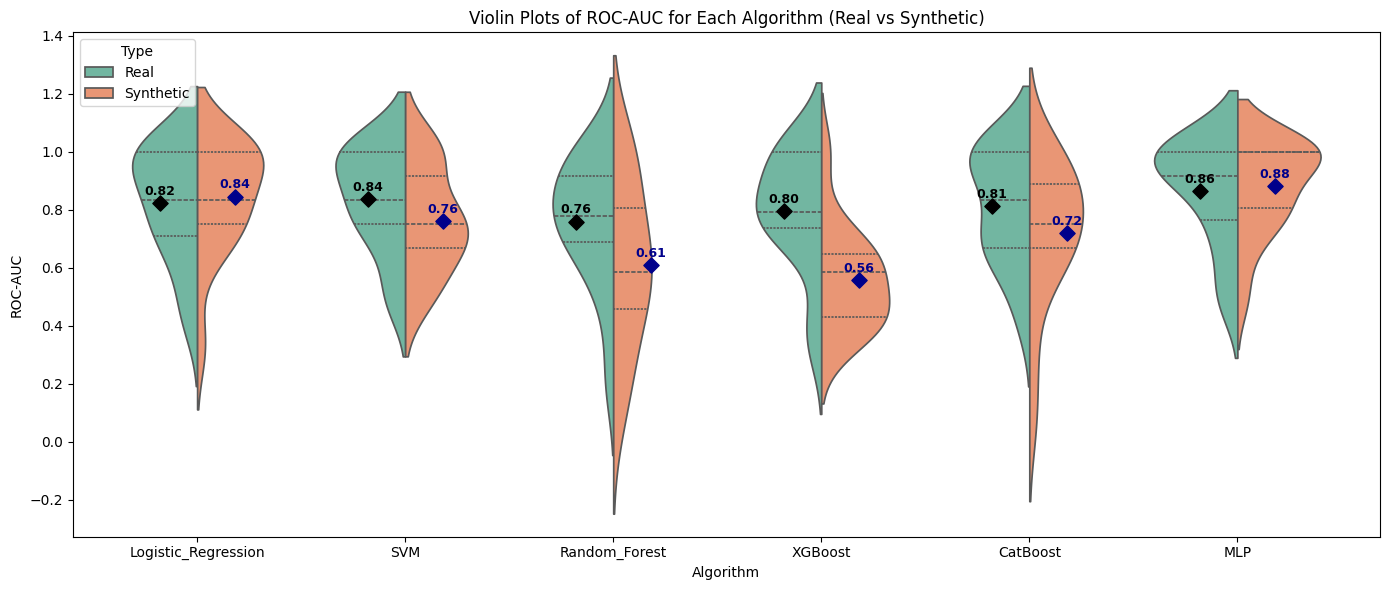

In [31]:
model_names = list(metric_results_cv.keys())
plot_violin_metric_pairs(metric_results_cv, model_names, metric_name="ROC-AUC")

In [89]:
models = {
    "Logistic_Regression": LogisticRegression(penalty = 'l2', max_iter = 100000, random_state=42, solver='lbfgs', n_jobs=-1),
    "SVM": SVC(probability = True, max_iter = 10000),
    "Random_Forest": RandomForestClassifier(random_state=42, n_jobs = -1),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42, thread_count=-1),
    "MLP":  MLPClassifier(alpha = 0.01, max_iter = 10000, validation_fraction = 0.1, random_state = 42, hidden_layer_sizes = 150)
}


n_splits = 5
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
n_neighbors = 5
return_full_scores = True

case = 'Ipi_Exp'
features = ['MHC-II','LN_Met_1','Tx_Start_LDH_lower','outcome']
syn_name = 'avatarsk10_42'
ori =  fullProcessedData['original_data'][case][features]
synth = fullProcessedData[syn_name][case][features]

metric_results_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_IpiTreated = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_cv[model_name] = cross_IpiTreated

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


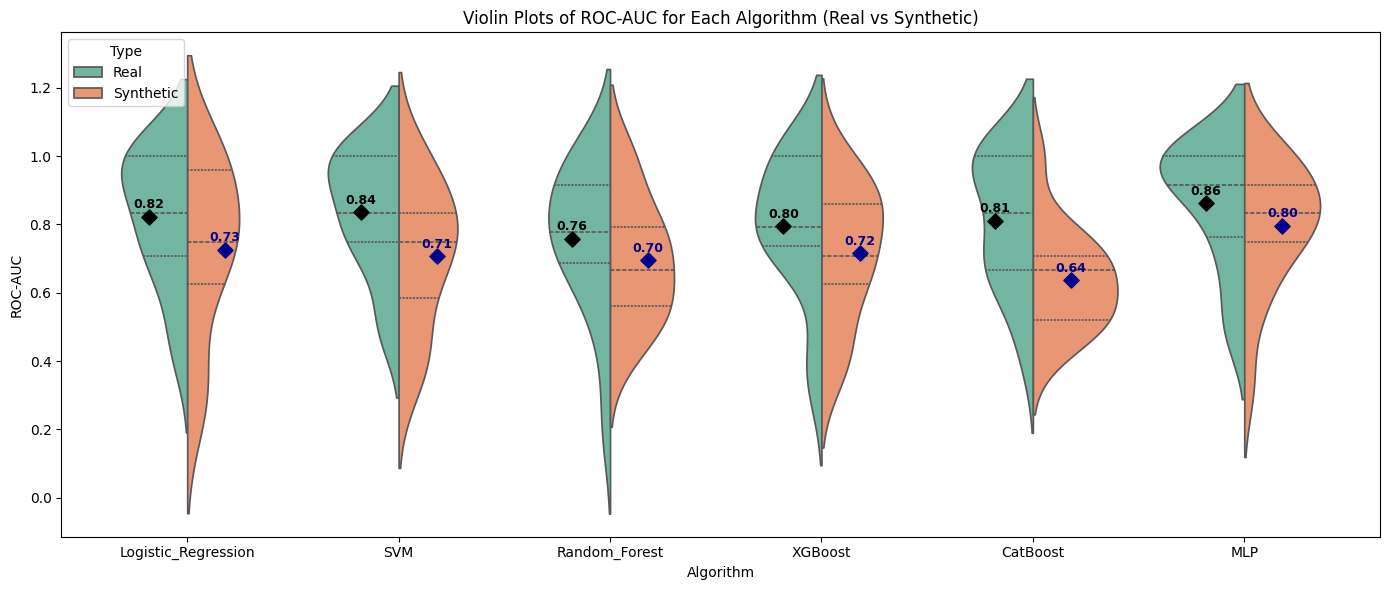

In [92]:
model_names = list(metric_results_cv.keys())
plot_violin_metric_pairs(metric_results_cv, model_names, metric_name="ROC-AUC")

In [93]:
models = {
    "Logistic_Regression": LogisticRegression(penalty = 'l2', max_iter = 100000, random_state=42, solver='lbfgs', n_jobs=-1),
    "SVM": SVC(probability = True, max_iter = 10000),
    "Random_Forest": RandomForestClassifier(random_state=42, n_jobs = -1),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42, thread_count=-1),
    "MLP":  MLPClassifier(alpha = 0.01, max_iter = 10000, validation_fraction = 0.1, random_state = 42, hidden_layer_sizes = 150)
}


n_splits = 5
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
n_neighbors = 5
return_full_scores = True

case = 'Ipi_Exp'
features = ['MHC-II','LN_Met_1','Tx_Start_LDH_lower','outcome']
syn_name = 'synthpop_42'
ori =  fullProcessedData['original_data'][case][features]
synth = fullProcessedData[syn_name][case][features]

metric_results_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_IpiTreated = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_cv[model_name] = cross_IpiTreated

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


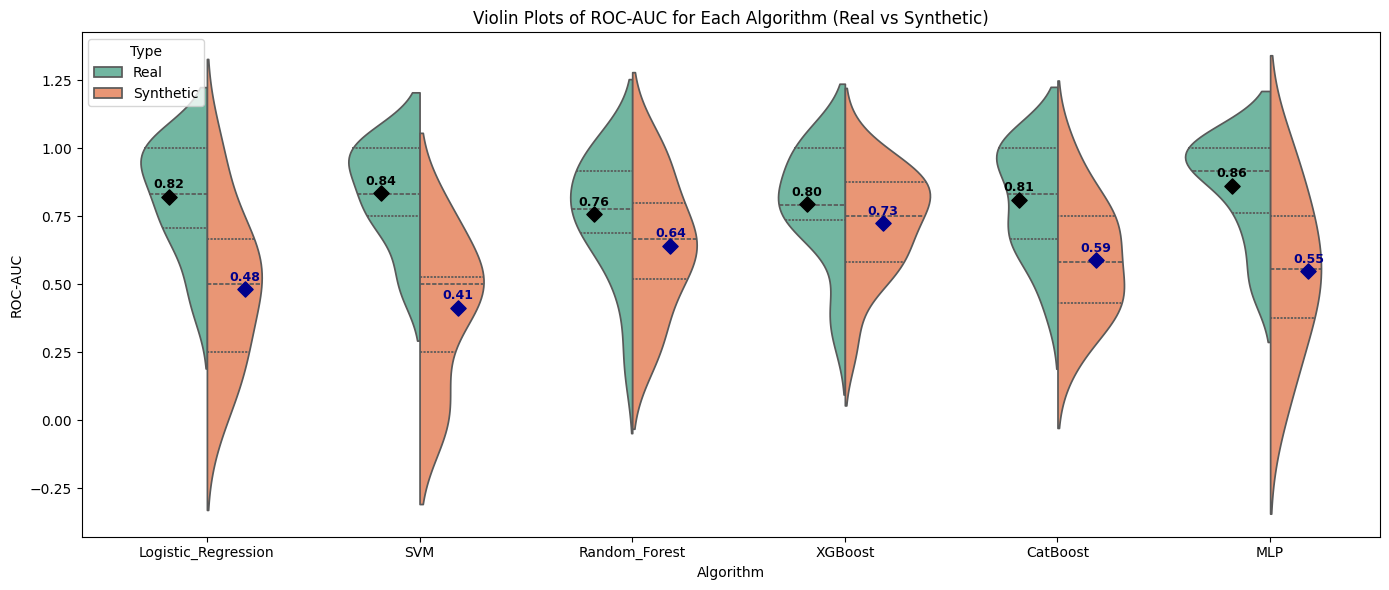

In [95]:
model_names = list(metric_results_cv.keys())
plot_violin_metric_pairs(metric_results_cv, model_names, metric_name="ROC-AUC")

In [96]:
models = {
    "Logistic_Regression": LogisticRegression(penalty = 'l2', max_iter = 100000, random_state=42, solver='lbfgs', n_jobs=-1),
    "SVM": SVC(probability = True, max_iter = 10000),
    "Random_Forest": RandomForestClassifier(random_state=42, n_jobs = -1),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42, thread_count=-1),
    "MLP":  MLPClassifier(alpha = 0.01, max_iter = 10000, validation_fraction = 0.1, random_state = 42, hidden_layer_sizes = 150)
}


n_splits = 5
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
n_neighbors = 5
return_full_scores = True

case = 'Ipi_Exp'
features = ['MHC-II','LN_Met_1','Tx_Start_LDH_lower','outcome']
syn_name = 'ctgan_42'
ori =  fullProcessedData['original_data'][case][features]
synth = fullProcessedData[syn_name][case][features]

metric_results_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_IpiTreated = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_cv[model_name] = cross_IpiTreated

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


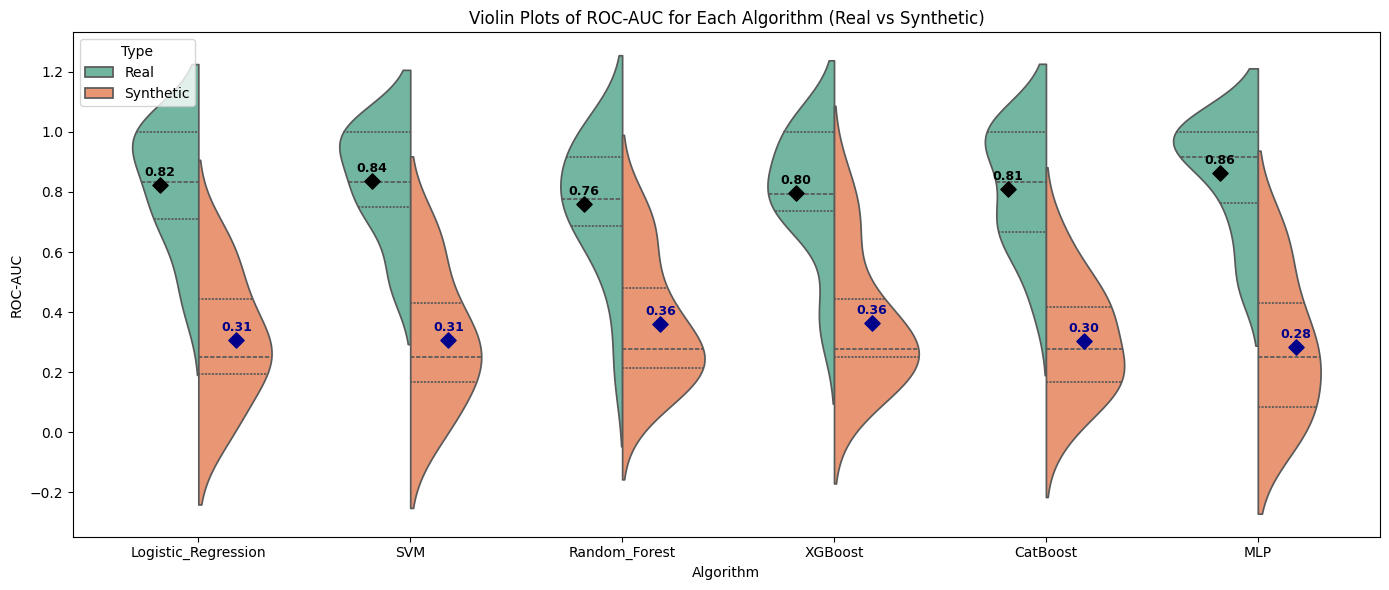

In [97]:
model_names = list(metric_results_cv.keys())
plot_violin_metric_pairs(metric_results_cv, model_names, metric_name="ROC-AUC")

In [98]:
models = {
    "Logistic_Regression": LogisticRegression(penalty = 'l2', max_iter = 100000, random_state=42, solver='lbfgs', n_jobs=-1),
    "SVM": SVC(probability = True, max_iter = 10000),
    "Random_Forest": RandomForestClassifier(random_state=42, n_jobs = -1),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42, thread_count=-1),
    "MLP":  MLPClassifier(alpha = 0.01, max_iter = 10000, validation_fraction = 0.1, random_state = 42, hidden_layer_sizes = 150)
}


n_splits = 5
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
n_neighbors = 5
return_full_scores = True

case = 'Ipi_Exp'
features = ['MHC-II','LN_Met_1','Tx_Start_LDH_lower','outcome']
syn_name = 'tvae_42'
ori =  fullProcessedData['original_data'][case][features]
synth = fullProcessedData[syn_name][case][features]

metric_results_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_IpiTreated = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_cv[model_name] = cross_IpiTreated

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


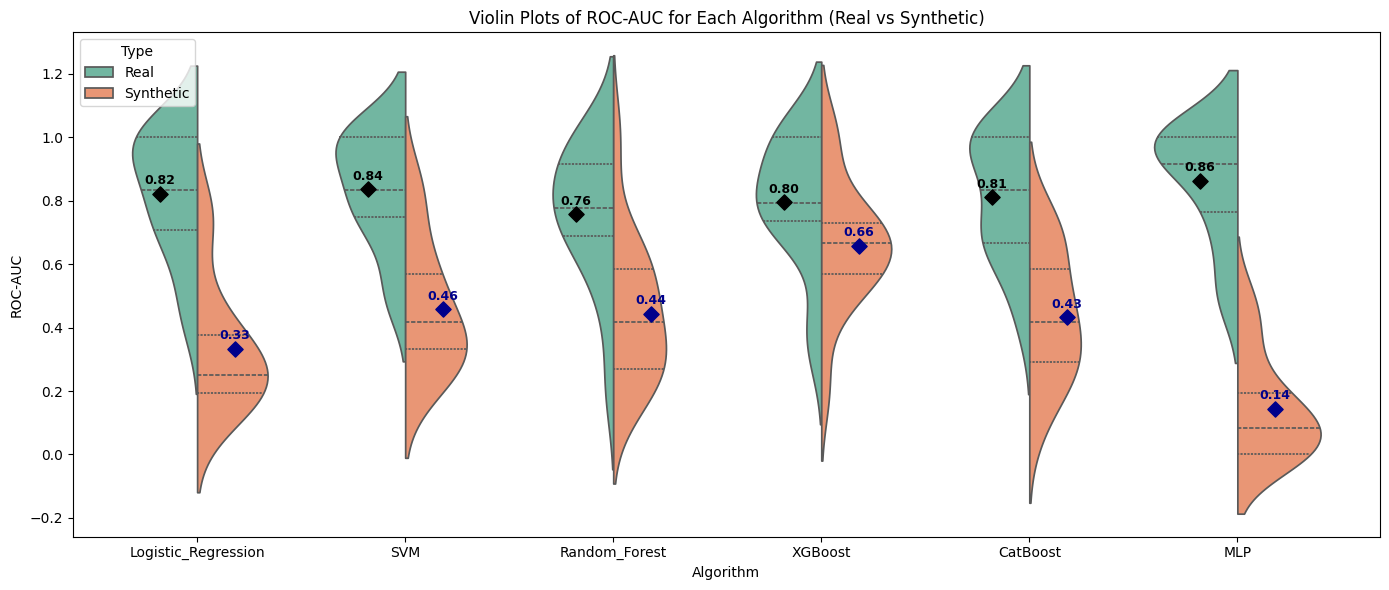

In [99]:
model_names = list(metric_results_cv.keys())
plot_violin_metric_pairs(metric_results_cv, model_names, metric_name="ROC-AUC")

## **Ipi Naive**

In [8]:
n_splits = 10
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
# n_neighbors = 5
return_full_scores = True

case = 'Ipi_Naive'
features = ['purity','ploidy','heterogeneity','outcome']
syn_name = 'gaussiancopula_42'
ori =  fullProcessedData['original_data'][case][features]
synth = fullProcessedData[syn_name][case][features]

metric_results_naive_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_naive = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_naive_cv[model_name] = cross_naive

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


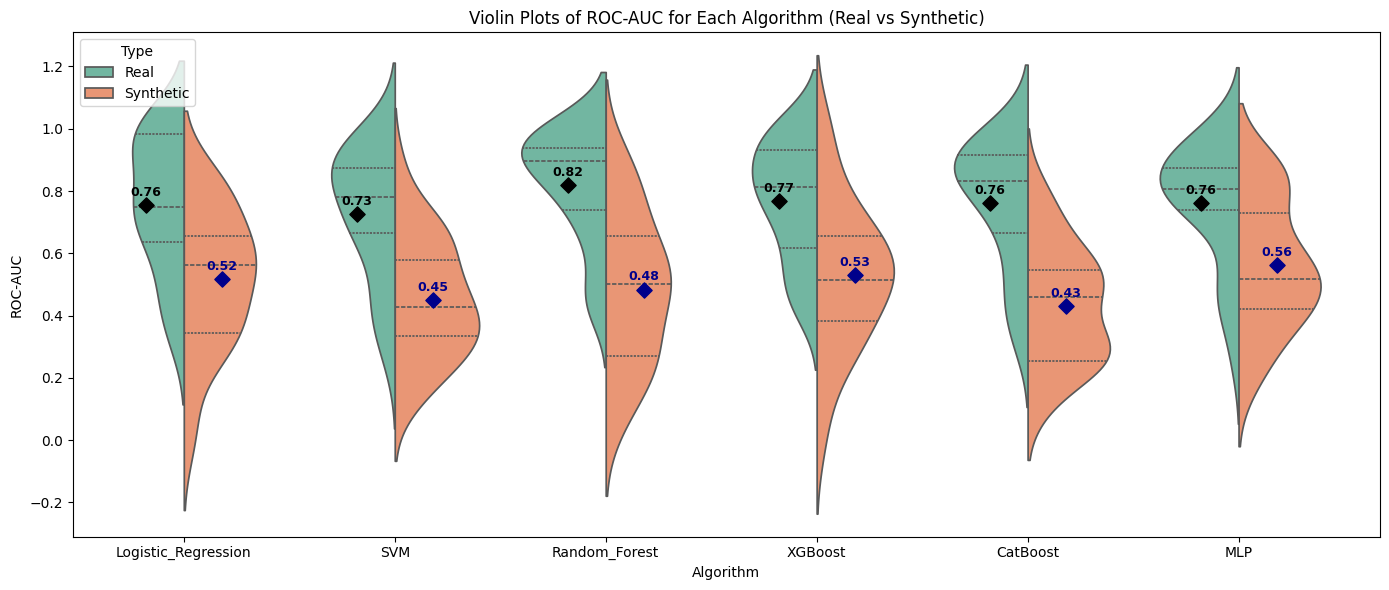

In [15]:
model_names = list(metric_results_naive_cv.keys())
plot_violin_metric_pairs(metric_results_naive_cv, model_names, metric_name="ROC-AUC")

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


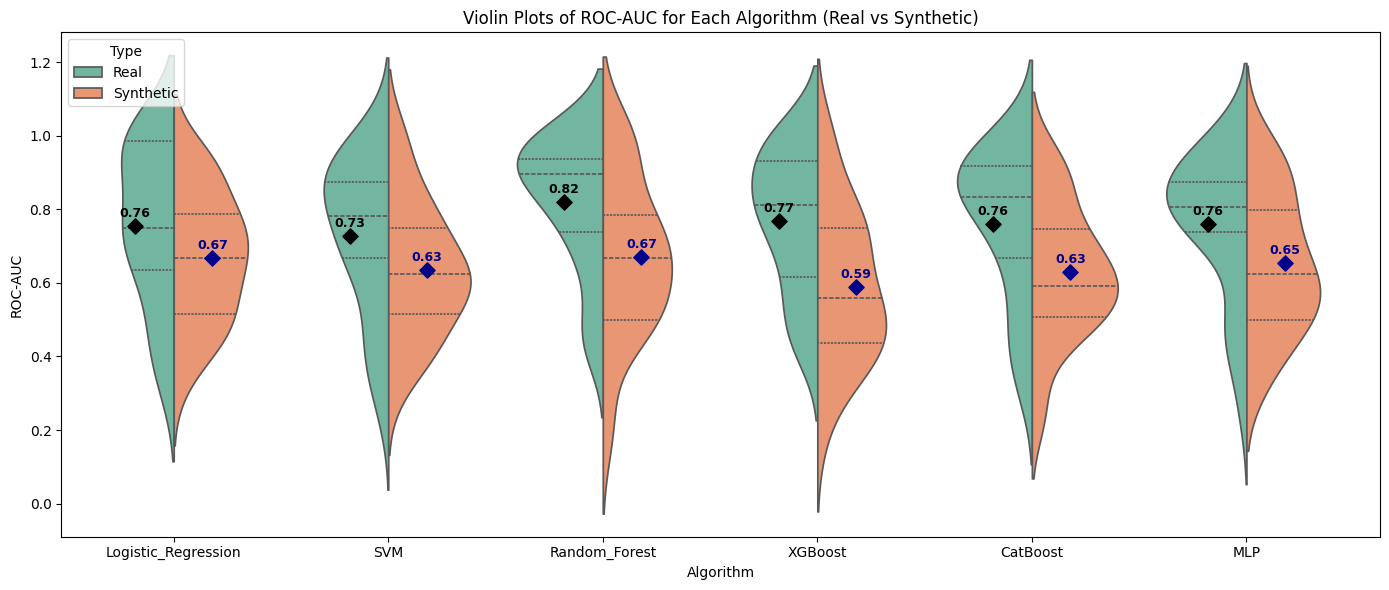

In [17]:
n_splits = 10
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
# n_neighbors = 5
return_full_scores = True

case = 'Ipi_Naive'
features = ['purity','ploidy','heterogeneity','outcome']
syn_name = 'avatarsk10_42'
ori =  fullProcessedData['original_data'][case][features]
synth = fullProcessedData[syn_name][case][features]

metric_results_naive_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_naive = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_naive_cv[model_name] = cross_naive

model_names = list(metric_results_naive_cv.keys())
plot_violin_metric_pairs(metric_results_naive_cv, model_names, metric_name="ROC-AUC")

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


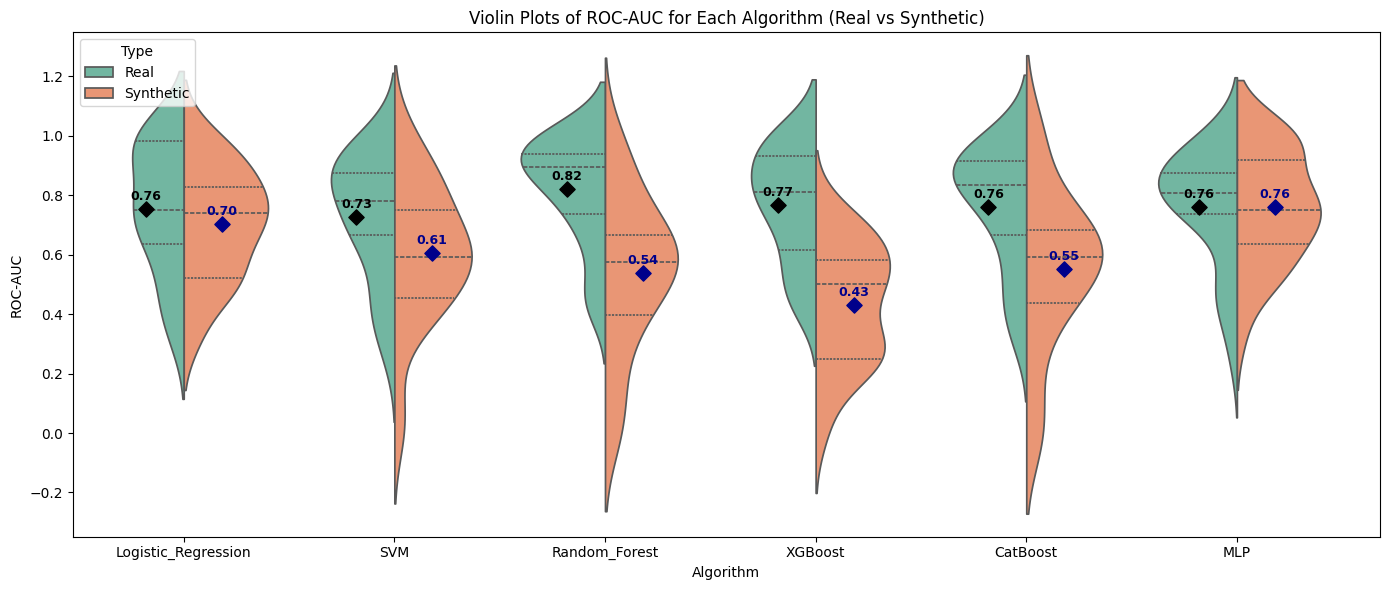

In [18]:
n_splits = 10
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
# n_neighbors = 5
return_full_scores = True

case = 'Ipi_Naive'
features = ['purity','ploidy','heterogeneity','outcome']
syn_name = 'synthpop_42'
ori =  fullProcessedData['original_data'][case][features]
synth = fullProcessedData[syn_name][case][features]

metric_results_naive_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_naive = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_naive_cv[model_name] = cross_naive

model_names = list(metric_results_naive_cv.keys())
plot_violin_metric_pairs(metric_results_naive_cv, model_names, metric_name="ROC-AUC")

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


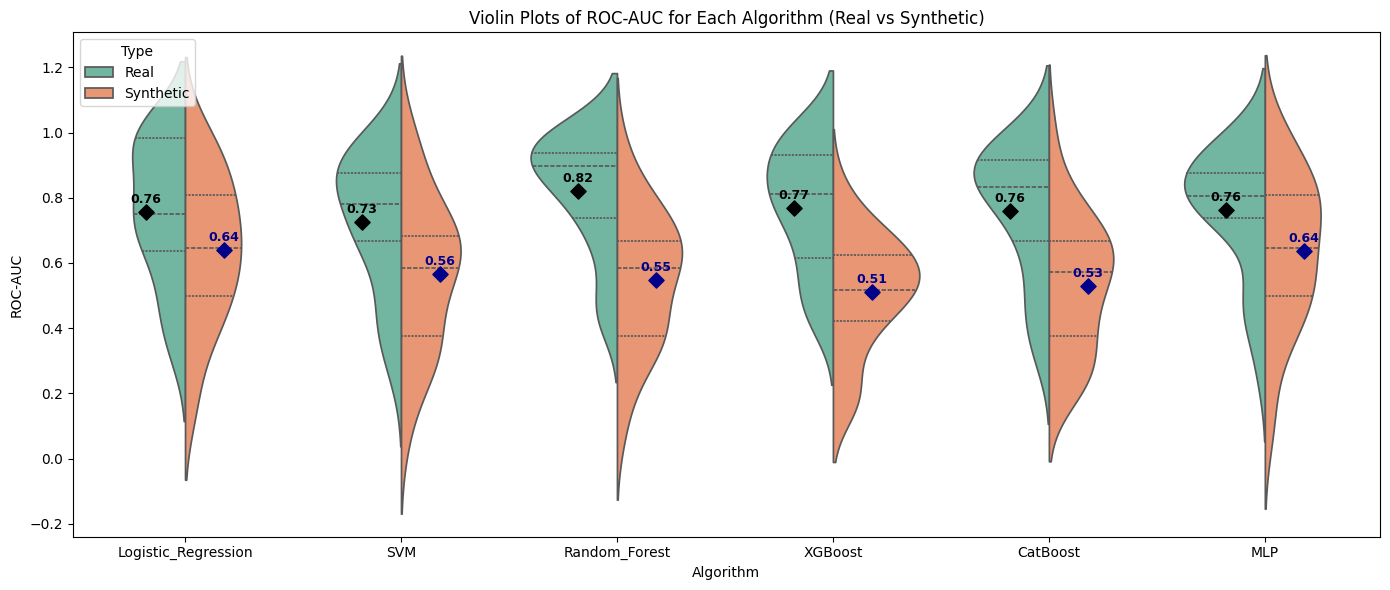

In [19]:
n_splits = 10
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
# n_neighbors = 5
return_full_scores = True

case = 'Ipi_Naive'
features = ['purity','ploidy','heterogeneity','outcome']
syn_name = 'ctgan_42'
ori =  fullProcessedData['original_data'][case][features]
synth = fullProcessedData[syn_name][case][features]

metric_results_naive_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_naive = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_naive_cv[model_name] = cross_naive

model_names = list(metric_results_naive_cv.keys())
plot_violin_metric_pairs(metric_results_naive_cv, model_names, metric_name="ROC-AUC")

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************


/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The l

************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************


/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The l

************************************************** MLP **************************************************


/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


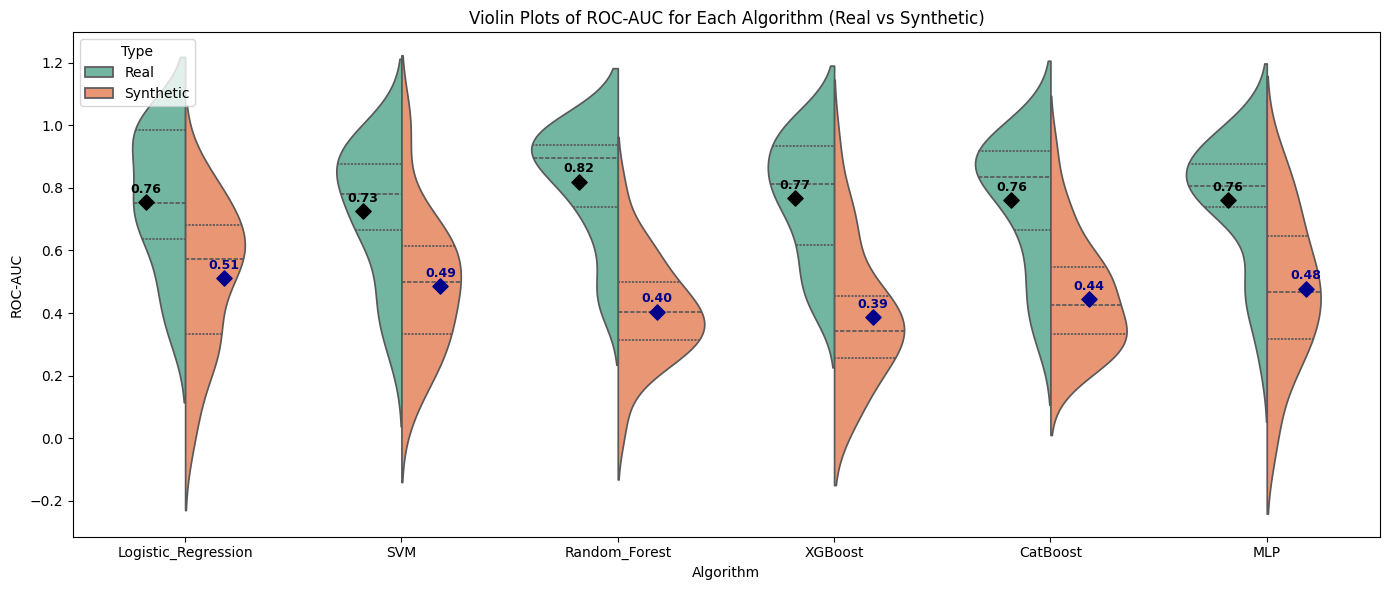

In [20]:
n_splits = 10
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
# n_neighbors = 5
return_full_scores = True

case = 'Ipi_Naive'
features = ['purity','ploidy','heterogeneity','outcome']
syn_name = 'tvae_42'
ori =  fullProcessedData['original_data'][case][features]
synth = fullProcessedData[syn_name][case][features]

metric_results_naive_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_naive = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_naive_cv[model_name] = cross_naive

model_names = list(metric_results_naive_cv.keys())
plot_violin_metric_pairs(metric_results_naive_cv, model_names, metric_name="ROC-AUC")

In [21]:
n_splits = 10
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
# n_neighbors = 5
return_full_scores = True

case = 'Ipi_Exp'
# features = ['purity','ploidy','heterogeneity','outcome']
syn_name = 'gaussiancopula_42'
ori =  fullProcessedData['original_data'][case]
synth = fullProcessedData[syn_name][case]

metric_results_all_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_exp_all = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_all_cv[model_name] = cross_exp_all

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


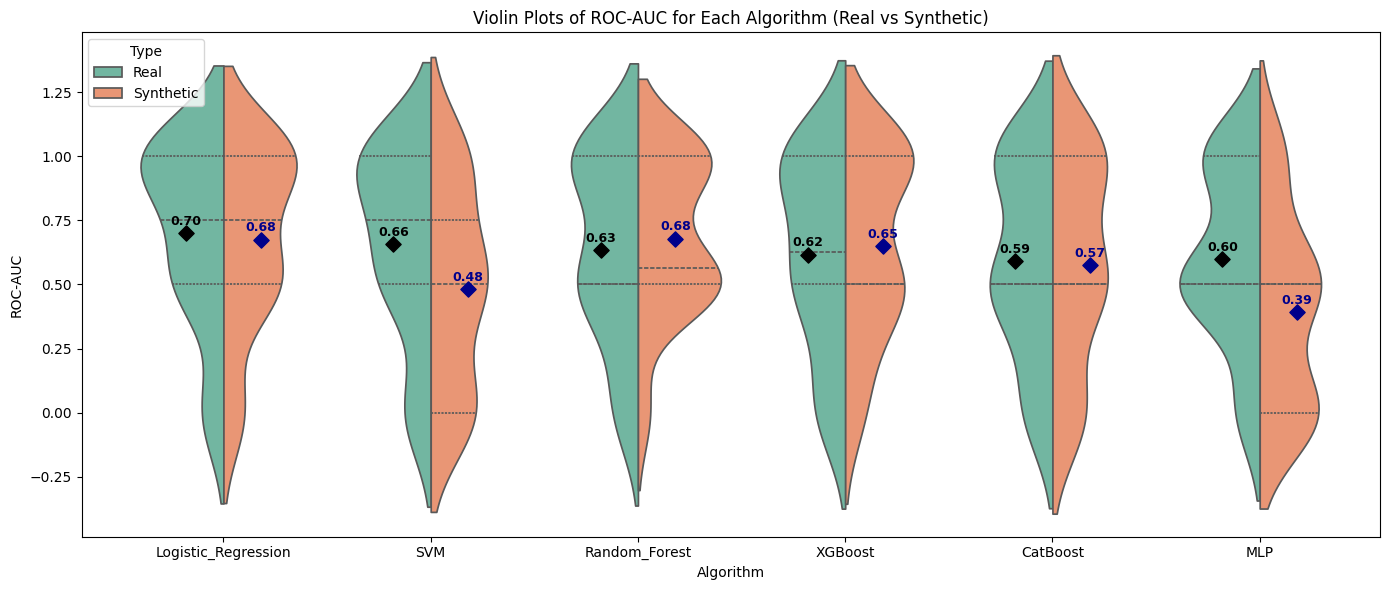

In [24]:
model_names = list(metric_results_all_cv.keys())
plot_violin_metric_pairs(metric_results_all_cv, model_names, metric_name="ROC-AUC")

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


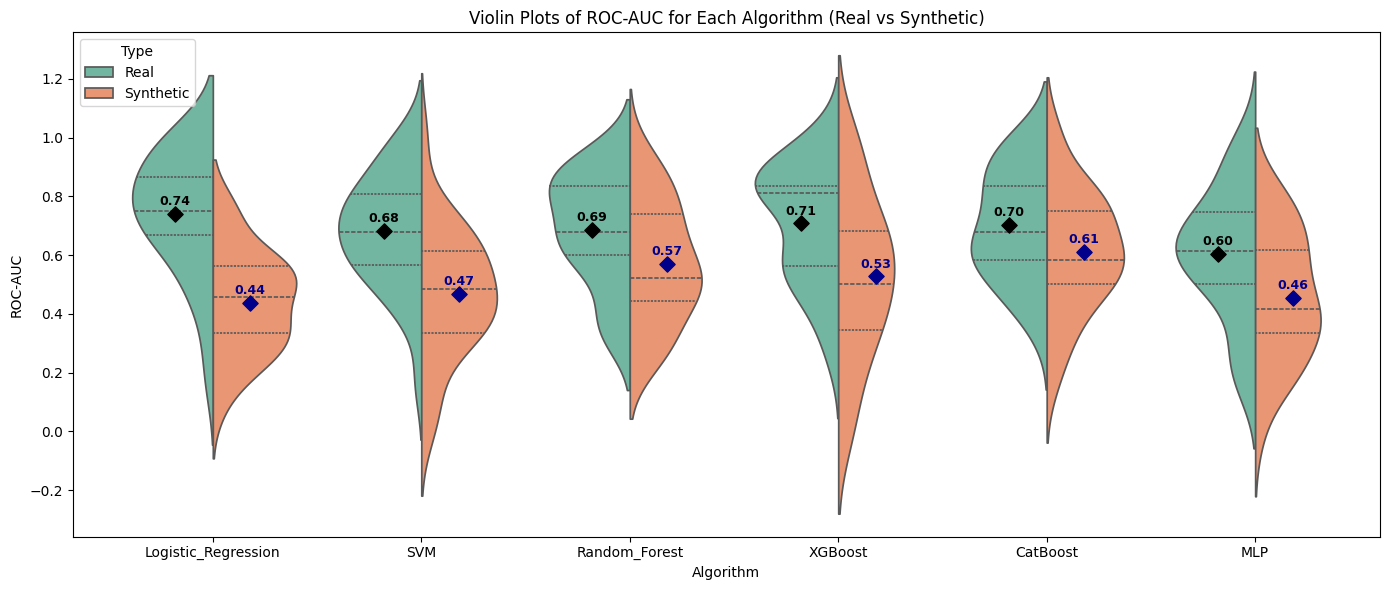

In [25]:
n_splits = 10
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
# n_neighbors = 5
return_full_scores = True

case = 'Ipi_Naive'
# features = ['purity','ploidy','heterogeneity','outcome']
syn_name = 'gaussiancopula_42'
ori =  fullProcessedData['original_data'][case]
synth = fullProcessedData[syn_name][case]

metric_results_all_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_exp_all = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_all_cv[model_name] = cross_exp_all
model_names = list(metric_results_all_cv.keys())
plot_violin_metric_pairs(metric_results_all_cv, model_names, metric_name="ROC-AUC")

************************************************** Logistic_Regression **************************************************
************************************************** SVM **************************************************
************************************************** Random_Forest **************************************************
************************************************** XGBoost **************************************************
************************************************** CatBoost **************************************************
************************************************** MLP **************************************************


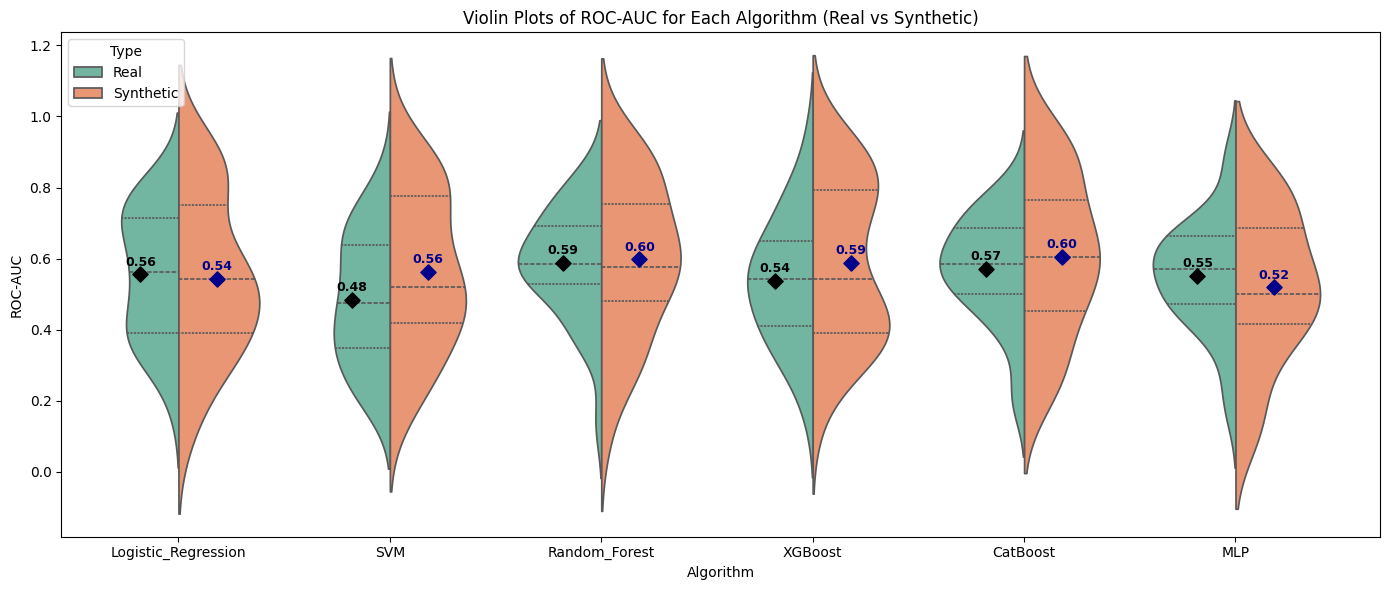

In [28]:
n_splits = 10
n_repeats = 3
metric = "roc_auc"
random_state = 42
cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=random_state
        )
random_state = 42
n_jobs = -1
target_col = "outcome"
output_dir = "ClassificationModel/"
scaler = "minmax"
# n_neighbors = 5
return_full_scores = True

case = 'PD_nPD'
# features = ['purity','ploidy','heterogeneity','outcome']
syn_name = 'gaussiancopula_42'
ori =  fullProcessedData['original_data'][case]
synth = fullProcessedData[syn_name][case]

metric_results_all_cv = {}
for model_name, model in models.items():
    print("*"*50, f"{model_name}", "*"*50)
    cross_exp_all = compare_cross_validation(
        real = ori,
        synth = synth,
        target_col = target_col,
        model = model,
        cv = cv,
        metric = metric,
        output_dir = output_dir,
        n_jobs = -1)
    metric_results_all_cv[model_name] = cross_exp_all

model_names = list(metric_results_all_cv.keys())
plot_violin_metric_pairs(metric_results_all_cv, model_names, metric_name="ROC-AUC")

In [27]:
fullProcessedData['original_data'].keys()

dict_keys(['Ipi_Exp', 'Ipi_Naive', 'PD_nPD'])

Optimization terminated successfully.
         Current function value: 0.621717
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                   37
Model:                          Logit   Df Residuals:                       33
Method:                           MLE   Df Model:                            3
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                 0.06264
Time:                        00:31:49   Log-Likelihood:                -23.004
converged:                       True   LL-Null:                       -24.541
Covariance Type:            nonrobust   LLR p-value:                    0.3803
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
MHC-II                -4.1907      2.556     -1.639      0.101      -9.201       0.820
LN_Me

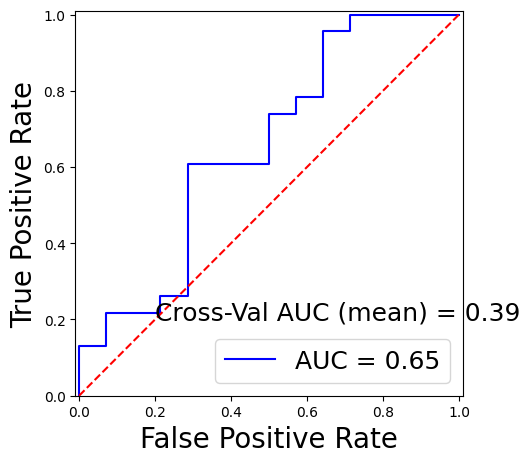

In [63]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
# Fig 5b - ROC and AUC for ipi-experienced model
outcomes = ['Ipi-exp PD vs nPD']
features = [
             'MHC-II',
                'LN_Met_1',
            'Tx_Start_LDH_lower',
           ]


figure = plt.figure(figsize = (5,5*len(outcomes)))
nrows = len(outcomes)
ncols = 1
gs = gridspec.GridSpec(nrows,ncols, height_ratios = [1]*len(outcomes), width_ratios = [1], 
                       wspace=0.05, hspace = 0.3)

for i, outcome in enumerate(outcomes):
    regDF = fullRegDFs[outcome]
    df = regDF[~regDF['outcome'].isnull()]
    for feature in features:
        if sum(df[feature].isnull()) > 0:
            print("removing", sum(df[feature].isnull()), "samples for null", feature,"value")
        df = df[~df[feature].isnull()]
        
    # add intercept
    df['intercept'] = 1
    logitModel = sm.Logit(df['outcome'], df[features + ['intercept']])
    result = logitModel.fit()
    print(result.summary())
    auc = roc_auc_score(df['outcome'], result.predict(df[features + ['intercept']]))
    print("AUC:", auc)
    fpr, tpr, threshold = roc_curve(df['outcome'], result.predict(df[features + ['intercept']]))
    crossval_scores = cross_val_score(LogisticRegression(), df[features + ['intercept']], 
                                      df['outcome'], scoring='roc_auc', cv=5)
    print(crossval_scores, crossval_scores.mean())

    ax = plt.subplot(gs[i])
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % auc)
    plt.legend(loc = 'lower right', prop={'size':18})
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([-0.01, 1.01])
    plt.ylim([0, 1.01])
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.text(0.2,0.2,"\nCross-Val AUC (mean) = %0.2f" % crossval_scores.mean(),size=18)

In [67]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

data = fullRegDFs['Ipi-exp PD vs nPD']
features = [
             'MHC-II',
                'LN_Met_1',
            'Tx_Start_LDH_lower',
           ]
X = data[features]
y = data['outcome']
# Random Forest model
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
log_reg = LogisticRegression(
    solver="liblinear",   # good for small datasets / binary classification
    penalty="l2",
    random_state=42
)

svm = SVC(
        kernel="rbf",
        probability=True,   # needed for AUC
        random_state=42
    )

# Repeated Stratified K-Fold
rskf = RepeatedStratifiedKFold(
    n_splits=5,      # 5-fold CV
    n_repeats=3,     # number of repeats (you can change)
    random_state=42
)

# Evaluate ROC-AUC
auc_scores = cross_val_score(
    log_reg,
    X,
    y,
    scoring="roc_auc",
    cv=rskf,
    n_jobs=-1
)

print("AUC scores:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))
print("Std AUC:", np.std(auc_scores))

AUC scores: [0.53333333 0.33333333 0.33333333 0.33333333 0.2        0.73333333
 0.26666667 0.41666667 0.41666667 0.3        0.2        0.46666667
 0.16666667 0.16666667 0.2       ]
Mean AUC: 0.33777777777777784
Std AUC: 0.1518364942550187


In [70]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

data = fullRegDFs['Ipi-naive PD vs nPD']
features = [
             'purity',
                'ploidy',
            'heterogeneity'
           ]
X = data[features]
y = data['outcome']
# Random Forest model
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
log_reg = LogisticRegression(
    solver="liblinear",   # good for small datasets / binary classification
    penalty="l2",
    random_state=42
)

svm = SVC(
        kernel="rbf",
        probability=True,   # needed for AUC
        random_state=42
    )

# Repeated Stratified K-Fold
rskf = RepeatedStratifiedKFold(
    n_splits=10,      # 10-fold CV
    n_repeats=3,     # number of repeats (you can change)
    random_state=42
)

# Evaluate ROC-AUC
auc_scores = cross_val_score(
    log_reg,
    X,
    y,
    scoring="roc_auc",
    cv=rskf,
    n_jobs=-1
)

print("AUC scores:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))
print("Std AUC:", np.std(auc_scores))

AUC scores: [0.73333333 0.66666667 0.8        0.73333333 0.66666667 0.83333333
 0.16666667 0.9        0.3        0.9        0.6        1.
 0.8        0.66666667 0.86666667 0.75       0.16666667 0.4
 0.4        0.6        0.73333333 0.86666667 0.66666667 0.33333333
 0.6        0.75       0.58333333 0.6        0.7        0.8       ]
Mean AUC: 0.6527777777777778
Std AUC: 0.2094562330899869
